# Case study 2

This case study will use simulated data for **daily all-cause emergency-department encounters** from 2022-01-01 through 2026-12-31, with a known **policy intervention on March 1, 2025**. The simulated data are saved to `../data/sim_ed_encounters.csv` for use by the downstream case-study notebook (`case_study2_policy_sim.ipynb`).

The daily mean rate combines:

- A baseline level (≈800 visits/day) plus a small upward trend (population growth).
- An annual seasonal cycle peaking in early January (respiratory season).
- A day-of-week multiplier (Monday highest, weekend lowest).
- A holiday multiplier (~−18% on US federal holidays).
- A **+12% level shift** beginning on the intervention date.

Daily counts are then drawn as `y ~ Poisson(rate)`. 

NOTE: Because the post-intervention effect is hard-coded, this notebook doubles as a sanity check. When `its2s` is run on the saved data, the estimated counterfactual and excess should recover an effect close to +12%.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.tseries.holiday import USFederalHolidayCalendar
from pathlib import Path

## 1 Configuration

In [3]:
SEED = 12345
rng = np.random.default_rng(SEED)

START = pd.Timestamp("2022-01-01")
END = pd.Timestamp("2026-12-31")
INTERVENTION = pd.Timestamp("2025-03-01")

# model parameters (additive + multiplicative, see markdown above).
BASELINE = 800.0                 # mean visits/day at the start of the series
TREND_PER_DAY = 0.05             # additive trend per day (~91 visits over 5 yr)
SEASONAL_AMPLITUDE = 80.0        # half-range of the annual cycle (visits/day)
SEASONAL_PEAK_DOY = 15           # day-of-year of the seasonal peak (mid-Jan)
DOW_FACTOR = {                   # day of week factor: mon=0 highest, sat=5 lowest
    0: 1.08, 1: 1.03, 2: 1.00, 3: 0.98,
    4: 0.96, 5: 0.93, 6: 0.97,
}
HOLIDAY_FACTOR = 0.82            # -18% on US federal holidays
INTERVENTION_EFFECT = 0.12       # +12% multiplicative level shift after intervention

dates = pd.date_range(START, END, freq="D")
n = len(dates)
t = np.arange(n)
print(f"Series length : {n:,} days  ({START.date()} \u2192 {END.date()})")
print(f"Intervention  : {INTERVENTION.date()}  (day {(INTERVENTION - START).days:,} of the series)")

Series length : 1,826 days  (2022-01-01 → 2026-12-31)
Intervention  : 2025-03-01  (day 1,155 of the series)


## 2 Build the daily mean rate

We assemble the deterministic rate $\lambda(t)$ in two layers:

- **Additive layer**: baseline + linear trend + annual cosine.
- **Multiplicative layer**: day-of-week factor, holiday factor, and the post-intervention level shift.

In [10]:
# Annual seasonality: cosine peaks at SEASONAL_PEAK_DOY.
day_of_year = dates.dayofyear.to_numpy()
seasonal = SEASONAL_AMPLITUDE * np.cos(2 * np.pi * (day_of_year - SEASONAL_PEAK_DOY) / 365.25)

# Day-of-week multiplier
dow_factor = np.array([DOW_FACTOR[d] for d in dates.dayofweek])

# Holiday mask (US federal calendar)
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=START, end=END)
is_holiday = np.asarray(dates.isin(holidays))

# Intervention indicator: 1 on/after the intervention date, 0 before.
post = np.asarray(dates >= INTERVENTION)

# Compose the daily mean rate.
mean_rate = BASELINE + TREND_PER_DAY * t + seasonal
mean_rate = mean_rate * dow_factor
mean_rate = np.where(is_holiday, mean_rate * HOLIDAY_FACTOR, mean_rate)
mean_rate = mean_rate * np.where(post, 1.0 + INTERVENTION_EFFECT, 1.0)

print(f"Mean rate (pre)      : {mean_rate[~post].mean():.1f} visits/day")
print(f"Mean rate (post)     : {mean_rate[post].mean():.1f} visits/day")
print(f"Naive pre/post ratio : {mean_rate[post].mean() / mean_rate[~post].mean() - 1:+.2%}")

Mean rate (pre)      : 821.8 visits/day
Mean rate (post)     : 960.1 visits/day
Naive pre/post ratio : +16.82%


## 3 Sample observed counts and save

Sample observed counts from a Poisson draw on the rate, which automatically gives count-appropriate variance ($\text{Var} = \mathbb{E}[y]$) without needing a separate noise term. We sample in order to simulate noise, so every point does not lie perfectly on the line. It essentially adds realistic variance. The output frame uses `its2s`' default column names (`ds`, `y`) so it can be loaded into the pipeline without renaming.

In [5]:
y = rng.poisson(mean_rate)

df = pd.DataFrame({"ds": dates, "y": y.astype(int)})

out_dir = Path("../data")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "sim_ed_encounters.csv"
df.to_csv(out_path, index=False)

print(f"Wrote {len(df):,} rows \u2192 {out_path.resolve()}")
df.head()

Wrote 1,826 rows → /Users/laurenwilner/Desktop/Desktop/epidemiology_PhD/00_repos/its2s/case_studies/case_study2_policy_sim/data/sim_ed_encounters.csv


,ds,y
0,2022-01-01,792
1,2022-01-02,879
2,2022-01-03,939
3,2022-01-04,913
4,2022-01-05,894


## 4 Visualize the simulated series

Visualization of the simulated series, including a 14-day rolling mean to make the trend, seasonality, and post-intervention level shift easier to spot against daily noise.

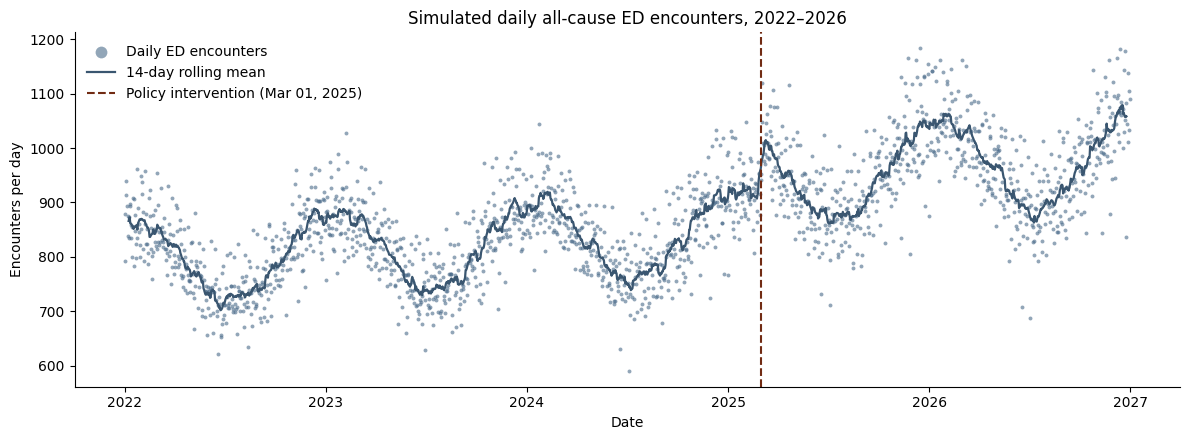

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(df["ds"], df["y"], s=8, color="#4a6b8a", alpha=0.6, linewidths=0,
           label="Daily ED encounters")

roll = df.set_index("ds")["y"].rolling(window=14, center=True).mean()
ax.plot(roll.index, roll.values, lw=1.6, color="#3a5670", label="14-day rolling mean")

ax.axvline(INTERVENTION, color="#712b13", linestyle="--", lw=1.5,
           label=f"Policy intervention ({INTERVENTION:%b %d, %Y})")

ax.set_title("Simulated daily all-cause ED encounters, 2022\u20132026", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Encounters per day")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", frameon=False, markerscale=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()